# Module 7 — USAD on SWaT

## Context

**Prior best result:** LSTM-AE, F1 **0.7533** on SWaT (Module 6, p99.9, 40 epochs).

**What USAD adds over a standard autoencoder.** A standard AE (Module 5) is trained with a single reconstruction loss: normal data and mildly anomalous data can produce similar errors, making threshold calibration brittle. USAD introduces a second decoder (D2) trained adversarially against the first (AE1 = E+D1). The adversarial term in the loss explicitly amplifies the error gap between normal and anomalous windows without requiring labeled anomalies.

**This module's hypothesis:** The adversarial amplification mechanism pushes USAD's F1 above LSTM-AE's 0.7533 on SWaT's slow drift attack scenarios.

## What USAD Is

**Architecture:** One shared encoder E, two decoders D1 and D2.

```
Input W → E → Z → D1 → W1   (AE1 reconstruction)
               ↓
              D2 → W2   (AE2 reconstruction)

W1 → E → Z' → D2 → W2_hat   (AE2 re-reconstruction of AE1's output)
```

**Training — single loop per batch (Algorithm 1):** Both losses computed in one forward pass. `n` = epoch index (1-indexed). As training progresses, `(1 − 1/n)` ramps from 0 to ~1.

$$\mathcal{L}_{AE_1} = \frac{1}{n}\|W - D_1(E(W))\|_2 + \left(1 - \frac{1}{n}\right)\|W - D_2(E(D_1(E(W))))\|_2 \quad (7)$$

$$\mathcal{L}_{AE_2} = \frac{1}{n}\|W - D_2(E(W))\|_2 - \left(1 - \frac{1}{n}\right)\|W - D_2(E(D_1(E(W))))\|_2 \quad (8)$$

AE1 (E+D1) minimises both its own reconstruction error and the adversarial term.  
AE2 (D2) minimises its own reconstruction but **maximises** the adversarial term.

**Inference — anomaly score (Algorithm 2, Eq 9):**

$$\mathcal{A}(\hat{W}) = \alpha\|\hat{W} - D_1(E(\hat{W}))\|_2 + \beta\|\hat{W} - D_2(E(D_1(E(\hat{W}))))\|_2$$

α and β are swept to find the best operating point. Higher β = more adversarial amplification.

## Section 0 — Imports & Config

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# --- Paths ---
# Original SUTD SWaT dataset files (comma decimal separator).
# normal: SWaT_Dataset_Normal_v1.csv  — 495,000 rows, no attacks
# attack: SWaT_Dataset_Attack_v0.csv  — 449,919 rows, ~12% attack rate
_KAGGLE_NORMAL = '/kaggle/input/datasets/eugenepeng/swat-original/SWaT_Dataset_Normal_v1.csv'
_KAGGLE_ATTACK = '/kaggle/input/datasets/eugenepeng/swat-original/SWaT_Dataset_Attack_v0.csv'

if os.path.exists(_KAGGLE_NORMAL):
    NORMAL_CSV = _KAGGLE_NORMAL
    ATTACK_CSV = _KAGGLE_ATTACK
else:
    NORMAL_CSV = '../data/SWaT/SWaT_Dataset_Normal_v1.csv'
    ATTACK_CSV = '../data/SWaT/SWaT_Dataset_Attack_v0.csv'

# --- Hyperparameters (paper defaults for SWaT) ---
DOWNSAMPLE    = 5        # block-median downsample factor
W             = 12       # window length
Z_DIM         = 80       # latent space size (increased from 40 for better reconstruction)
EPOCHS_PHASE1 = 20       # pure reconstruction warm-up (no adversarial term)
EPOCHS_PHASE2 = 50       # adversarial training (epoch-weighted, n resets to 1)
BATCH_SIZE    = 1024     # larger batch for stable adversarial training

# α/β pairs for inference sensitivity sweep (α + β = 1 per paper)
ALPHA_BETA  = [(1.0, 0.0), (0.5, 0.5), (0.1, 0.9), (0.01, 0.99)]

# Percentile sweep: test attack rate is ~12%, so optimal threshold
# is near p88. Sweep p80–p99.9 to find the F1-maximising percentile.
PERCENTILES = [80, 85, 88, 90, 92, 95, 99, 99.9]

# --- Reproducibility ---
torch.manual_seed(42)
np.random.seed(42)

# --- Device ---
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

N_FEATURES = None  # set after data loading (51 for SWaT)

print(f'Device: {DEVICE}')
print(f'Normal: {NORMAL_CSV}')
print(f'Attack: {ATTACK_CSV}')
print(f'W={W}  |  Z_DIM={Z_DIM}  |  DOWNSAMPLE={DOWNSAMPLE}')
print(f'Phase 1 epochs (pure reconstruction): {EPOCHS_PHASE1}')
print(f'Phase 2 epochs (adversarial):         {EPOCHS_PHASE2}')
print(f'BATCH_SIZE={BATCH_SIZE}')

Device: cuda
Normal: /kaggle/input/datasets/eugenepeng/swat-original/SWaT_Dataset_Normal_v1.csv
Attack: /kaggle/input/datasets/eugenepeng/swat-original/SWaT_Dataset_Attack_v0.csv
W=12  |  Z_DIM=80  |  DOWNSAMPLE=5
Phase 1 epochs (pure reconstruction): 20
Phase 2 epochs (adversarial):         50
BATCH_SIZE=1024


## Section 1 — Data Loading

Load the original SUTD SWaT dataset files, matching the original author's preprocessing exactly:

- **`SWaT_Dataset_Normal_v1.csv`** — 495,000 rows, normal operation (7 days, Dec 22–28 2015). No attacks. Used for training.
- **`SWaT_Dataset_Attack_v0.csv`** — 449,919 rows, attack period (4 days, Dec 28 2015–Jan 2 2016). ~12% labeled Attack. Used for test.

Both files use **comma as the decimal separator** (European format) and require comma→dot replacement before casting to float. The attack file additionally uses **semicolons as the field separator**.

MinMaxScaler is fit on normal data only and applied (`.transform`) to attack data — no re-fitting on test data.

In [2]:
def load_swat(path, sep=','):
    """Load a SWaT CSV, strip column names, replace comma decimals, cast to float."""
    df = pd.read_csv(path, sep=sep, low_memory=False)
    df.columns = df.columns.str.strip()
    # Original files use comma as decimal separator (European format).
    # Replace commas with dots before casting to float — matches original author's preprocessing.
    for col in df.columns:
        if col not in ('Timestamp', 'Normal/Attack'):
            df[col] = df[col].apply(lambda x: str(x).replace(',', '.')).astype(float)
    return df

normal_df = load_swat(NORMAL_CSV)
attack_df = load_swat(ATTACK_CSV, sep=';')

print(f'Normal: {len(normal_df):,} rows  |  Attack: {len(attack_df):,} rows')
print(f'Normal first ts: {normal_df["Timestamp"].iloc[0].strip()}')
print(f'Attack first ts: {attack_df["Timestamp"].iloc[0].strip()}')

# Feature columns: all except Timestamp and Normal/Attack (51 SWaT features)
feature_cols = [c for c in normal_df.columns if c not in ('Timestamp', 'Normal/Attack')]
N_FEATURES   = len(feature_cols)
INPUT_SIZE   = W * N_FEATURES

print(f'\nFeatures: {N_FEATURES}  |  Input size (W×N): {W}×{N_FEATURES} = {INPUT_SIZE}')
print(f'Encoder: {INPUT_SIZE} → {INPUT_SIZE//2} → {INPUT_SIZE//4} → {Z_DIM}')

# Labels: 1 = Attack, 0 = Normal
labels_test = (attack_df['Normal/Attack'].str.strip() == 'Attack').astype(int).values
print(f'\nTest attack rate: {labels_test.mean():.2%}')

# Extract raw feature arrays
X_train_raw = normal_df[feature_cols].values.astype(np.float32)
X_test_raw  = attack_df[feature_cols].values.astype(np.float32)

# Block-median downsampling — applied to both for timescale consistency.
# Label rule: OR (max) — a block is Attack if ANY of its 5 rows is an attack.
def block_median_downsample(X, factor):
    n_groups = len(X) // factor
    return np.median(
        X[:n_groups * factor].reshape(n_groups, factor, X.shape[1]),
        axis=1
    ).astype(np.float32)

def block_label_downsample(labels, factor):
    n_groups = len(labels) // factor
    return labels[:n_groups * factor].reshape(n_groups, factor).max(axis=1)

X_train_ds = block_median_downsample(X_train_raw, DOWNSAMPLE)
X_test_ds  = block_median_downsample(X_test_raw,  DOWNSAMPLE)
y_true     = block_label_downsample(labels_test,  DOWNSAMPLE)

print(f'\nAfter block-median downsampling (÷{DOWNSAMPLE}):')
print(f'  Train: {len(X_train_ds):,} rows | attack rate: 0.00%')
print(f'  Test:  {len(X_test_ds):,} rows  | attack rate: {y_true.mean():.2%}')

# MinMaxScaler fit on normal data only, transform applied to both.
# Matches original author's preprocessing exactly.
scaler         = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_ds).astype(np.float32)
X_test_scaled  = scaler.transform(X_test_ds).astype(np.float32)

print(f'\nScaled ranges:')
print(f'  Train: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]  mean: {X_train_scaled.mean():.4f}')
print(f'  Test:  [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]  mean: {X_test_scaled.mean():.4f}')

Normal: 495,000 rows  |  Attack: 449,919 rows
Normal first ts: 22/12/2015 4:30:00 PM
Attack first ts: 28/12/2015 10:00:00 AM

Features: 51  |  Input size (W×N): 12×51 = 612
Encoder: 612 → 306 → 153 → 80

Test attack rate: 12.13%

After block-median downsampling (÷5):
  Train: 99,000 rows | attack rate: 0.00%
  Test:  89,983 rows  | attack rate: 12.16%

Scaled ranges:
  Train: [0.0000, 1.0000]  mean: 0.5132
  Test:  [-4.0092, 2.1981]  mean: 0.4384


## Section 2 — Window Dataset

USAD operates on flattened windows of shape `(W × N_FEATURES,)`. Rather than a custom `Dataset` with per-item slicing, we pre-materialise all training windows at once using numpy stride tricks — a single vectorised operation. This eliminates 99K Python `__getitem__` calls per epoch and cuts data-loading overhead to near zero.

In [3]:
# Pre-materialise all training windows and move to DEVICE once.
# Eliminates per-batch CPU→GPU transfers (critical for GPU performance).
n_train   = len(X_train_scaled)
n_windows = n_train - W + 1

windows = np.lib.stride_tricks.as_strided(
    X_train_scaled,
    shape=(n_windows, W, N_FEATURES),
    strides=(X_train_scaled.strides[0], X_train_scaled.strides[0], X_train_scaled.strides[1]),
).reshape(n_windows, W * N_FEATURES).copy()           # (n_windows, 612)

# Move entire tensor to device once — no per-batch CPU→GPU transfers during training
train_tensor  = torch.FloatTensor(windows).to(DEVICE)
train_dataset = TensorDataset(train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
del windows  # free numpy copy

print(f'Training windows (stride=1): {len(train_dataset):,}')
print(f'Window shape: flattened ({W} × {N_FEATURES}) = {W * N_FEATURES}')
print(f'Batches per epoch: {len(train_loader):,}')
print(f'train_tensor: {train_tensor.shape}, device={train_tensor.device}')

Training windows (stride=1): 98,989
Window shape: flattened (12 × 51) = 612
Batches per epoch: 97
train_tensor: torch.Size([98989, 612]), device=cuda:0


## Section 3 — Model Definition

Architecture per Appendix A.4 of the paper:
- **Encoder:** 3 linear layers, halving each time — `[INPUT_SIZE → INPUT_SIZE/2 → INPUT_SIZE/4 → Z_DIM]`, ReLU after each
- **Decoder (both D1 and D2):** 3 linear layers, doubling — `[Z_DIM → INPUT_SIZE/4 → INPUT_SIZE/2 → INPUT_SIZE]`, ReLU after first two, **Sigmoid** on output

In [4]:
class Encoder(nn.Module):
    """Three-layer MLP: INPUT_SIZE → INPUT_SIZE/2 → INPUT_SIZE/4 → Z_DIM (ReLU after each)."""
    def __init__(self, input_size: int, z_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size,      input_size // 2), nn.ReLU(),
            nn.Linear(input_size // 2, input_size // 4), nn.ReLU(),
            nn.Linear(input_size // 4, z_dim),           nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    """Three-layer MLP: Z_DIM → INPUT_SIZE/4 → INPUT_SIZE/2 → INPUT_SIZE.
    ReLU after first two layers, Sigmoid on output (Appendix A.4).
    """
    def __init__(self, input_size: int, z_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim,           input_size // 4), nn.ReLU(),
            nn.Linear(input_size // 4, input_size // 2), nn.ReLU(),
            nn.Linear(input_size // 2, input_size),      nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class USAD(nn.Module):
    """USAD: one shared encoder E, two decoders D1 and D2.

    AE1 = E + D1: learns to reconstruct W and fool D2.
    AE2 = E + D2: learns to reconstruct W and detect AE1's output.

    Forward pass returns:
        w1     = D1(E(W))            AE1 reconstruction
        w2     = D2(E(W))            AE2 reconstruction
        w2_hat = D2(E(D1(E(W))))     AE2 applied to re-encoded AE1 output
    """
    def __init__(self, input_size: int, z_dim: int):
        super().__init__()
        self.E  = Encoder(input_size, z_dim)
        self.D1 = Decoder(input_size, z_dim)
        self.D2 = Decoder(input_size, z_dim)

    def forward(self, w):
        z      = self.E(w)
        w1     = self.D1(z)
        w2     = self.D2(z)
        w2_hat = self.D2(self.E(w1))  # re-encode AE1's output, then decode with D2
        return w1, w2, w2_hat


# Instantiate
model = USAD(INPUT_SIZE, Z_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
e_params     = sum(p.numel() for p in model.E.parameters())
d_params     = sum(p.numel() for p in model.D1.parameters())  # D1 == D2 size

print(f'Input size: {INPUT_SIZE}  ({INPUT_SIZE//2}, {INPUT_SIZE//4}, {Z_DIM})')
print(f'Encoder params: {e_params:,}')
print(f'Decoder params (each): {d_params:,}')
print(f'Total trainable params: {total_params:,}  (E + D1 + D2)')

Input size: 612  (306, 153, 80)
Encoder params: 246,869
Decoder params (each): 247,401
Total trainable params: 741,671  (E + D1 + D2)


## Section 4 — Training

**Two-phase training strategy:**

The core problem with single-phase adversarial training is that the epoch-weighted schedule `(1 - 1/n)` makes the adversarial term dominant very quickly (by epoch 3 it outweighs reconstruction 2:1, by epoch 10 it's 9:1). If AE1 hasn't converged yet, D2 has nothing meaningful to compete against — the adversarial game starts before either decoder knows what "normal" looks like.

**Phase 1 — Pure reconstruction (20 epochs):** Both AEs minimise their own reconstruction error independently (Eq 4 from the paper):
- $\mathcal{L}_{AE_1}^{(1)} = \| W - \hat{W}_1 \|_2$ (MSE between input and AE1 output)
- $\mathcal{L}_{AE_2}^{(1)} = \| W - \hat{W}_2 \|_2$ (MSE between input and AE2 output)

**Phase 2 — Adversarial training (50 epochs, n resets to 1):** The full epoch-weighted adversarial equations engage with a freshly-reset epoch counter `n`:
- $\mathcal{L}_{AE_1}^{(2)} = \frac{1}{n}\| W - \hat{W}_1 \|_2 + (1 - \frac{1}{n})\| W - \hat{W}_{2}^{\prime\prime} \|_2$
- $\mathcal{L}_{AE_2}^{(2)} = \frac{1}{n}\| W - \hat{W}_2 \|_2 - (1 - \frac{1}{n})\| W - \hat{W}_{2}^{\prime\prime} \|_2$

The epoch counter `n` resets to 1 at the start of Phase 2 so the transition from reconstruction-dominant to adversarial-dominant happens gradually again — now with both decoders already trained.

**Two separate Adam optimizers** (both include the shared encoder):
- `opt1` owns E + D1 — updated with $\mathcal{L}_{AE_1}$
- `opt2` owns E + D2 — updated with $\mathcal{L}_{AE_2}$

**Two forward passes per batch** — sequential, no `retain_graph=True` needed.

In [5]:
# Two separate optimizers — both include encoder (E is shared, updated by each)
opt1 = torch.optim.Adam(list(model.E.parameters()) + list(model.D1.parameters()))
opt2 = torch.optim.Adam(list(model.E.parameters()) + list(model.D2.parameters()))

epoch_loss1 = []
epoch_loss2 = []

# ── Phase 1: Pure reconstruction warm-up ────────────────────────────────────
# Both AEs train on their own reconstruction error only (Eq 4 of paper).
# No adversarial term — lets E, D1, D2 converge before the game starts.
print(f'=== Phase 1: Pure reconstruction ({EPOCHS_PHASE1} epochs) ===')
print(f'Training on {DEVICE} | {len(train_dataset):,} windows | batch {BATCH_SIZE}')
print('-' * 65)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    model.train()
    total_l1 = total_l2 = 0.0
    n_batches = 0

    for (batch,) in train_loader:
        # Train AE1 (E + D1) — pure reconstruction
        w1, w2, w2_hat = model(batch)
        loss1 = torch.mean((batch - w1) ** 2)
        loss1.backward()
        opt1.step()
        opt1.zero_grad()

        # Train AE2 (E + D2) — pure reconstruction (second forward pass)
        w1, w2, w2_hat = model(batch)
        loss2 = torch.mean((batch - w2) ** 2)
        loss2.backward()
        opt2.step()
        opt2.zero_grad()

        total_l1 += loss1.item()
        total_l2 += loss2.item()
        n_batches += 1

    avg_l1 = total_l1 / n_batches
    avg_l2 = total_l2 / n_batches
    epoch_loss1.append(avg_l1)
    epoch_loss2.append(avg_l2)

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS_PHASE1}  AE1: {avg_l1:.6f}  AE2: {avg_l2:.6f}')

print(f'Phase 1 done — AE1: {epoch_loss1[-1]:.6f}  |  AE2: {epoch_loss2[-1]:.6f}')
print()

# ── Phase 2: Adversarial training ───────────────────────────────────────────
# Epoch counter n resets to 1 so the (1-1/n) schedule ramps up again from 0,
# now with both decoders already warmed up from Phase 1.
print(f'=== Phase 2: Adversarial training ({EPOCHS_PHASE2} epochs) ===')
print(f'Adversarial weight (1-1/n): epoch 1 → 0.000,  epoch {EPOCHS_PHASE2} → {1 - 1/EPOCHS_PHASE2:.3f}')
print('-' * 65)

for epoch in range(1, EPOCHS_PHASE2 + 1):
    model.train()
    n = epoch  # epoch counter resets to 1 for phase 2

    total_l1 = total_l2 = 0.0
    n_batches = 0

    for (batch,) in train_loader:
        # Train AE1 (E + D1) — reconstruction + adversarial
        w1, w2, w2_hat = model(batch)
        loss1 = (1/n) * torch.mean((batch - w1) ** 2) + (1 - 1/n) * torch.mean((batch - w2_hat) ** 2)
        loss1.backward()
        opt1.step()
        opt1.zero_grad()

        # Train AE2 (E + D2) — reconstruction - adversarial (second forward pass)
        w1, w2, w2_hat = model(batch)
        loss2 = (1/n) * torch.mean((batch - w2) ** 2) - (1 - 1/n) * torch.mean((batch - w2_hat) ** 2)
        loss2.backward()
        opt2.step()
        opt2.zero_grad()

        total_l1 += loss1.item()
        total_l2 += loss2.item()
        n_batches += 1

    avg_l1 = total_l1 / n_batches
    avg_l2 = total_l2 / n_batches
    epoch_loss1.append(avg_l1)
    epoch_loss2.append(avg_l2)

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS_PHASE2}  AE1: {avg_l1:.6f}  AE2: {avg_l2:.6f}  adv_w={(1-1/n):.3f}')

print('-' * 65)
print(f'Final — AE1: {epoch_loss1[-1]:.6f}  |  AE2: {epoch_loss2[-1]:.6f}')

=== Phase 1: Pure reconstruction (20 epochs) ===
Training on cuda | 98,989 windows | batch 1024
-----------------------------------------------------------------
  Epoch   1/20  AE1: 0.042171  AE2: 0.041301
  Epoch   5/20  AE1: 0.003133  AE2: 0.003183
  Epoch  10/20  AE1: 0.002025  AE2: 0.002183
  Epoch  15/20  AE1: 0.001518  AE2: 0.001632
  Epoch  20/20  AE1: 0.001321  AE2: 0.001474
Phase 1 done — AE1: 0.001321  |  AE2: 0.001474

=== Phase 2: Adversarial training (50 epochs) ===
Adversarial weight (1-1/n): epoch 1 → 0.000,  epoch 50 → 0.980
-----------------------------------------------------------------
  Epoch   1/50  AE1: 0.001550  AE2: 0.001854  adv_w=0.000
  Epoch  10/50  AE1: 0.018305  AE2: -0.016929  adv_w=0.900
  Epoch  20/50  AE1: 0.128841  AE2: -0.121898  adv_w=0.950
  Epoch  30/50  AE1: 0.131000  AE2: -0.126411  adv_w=0.967
  Epoch  40/50  AE1: 0.132713  AE2: -0.129272  adv_w=0.975
  Epoch  50/50  AE1: 0.133485  AE2: -0.130737  adv_w=0.980
---------------------------------

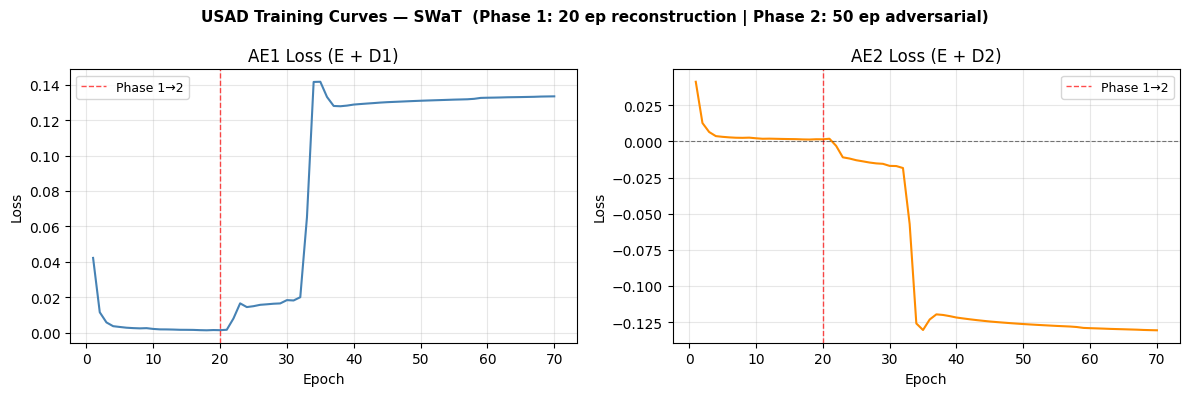

Phase 1 final — AE1: 0.001321  AE2: 0.001474
Phase 2 final — AE1: 0.133485  AE2: -0.130737
Note: AE2 loss goes negative in Phase 2 — the adversarial term (which AE2 maximises) dominates.


In [6]:
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2
epochs_x = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, epoch_loss1, color='steelblue', linewidth=1.5)
ax1.axvline(EPOCHS_PHASE1, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Phase 1→2')
ax1.set_title('AE1 Loss (E + D1)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, epoch_loss2, color='darkorange', linewidth=1.5)
ax2.axvline(EPOCHS_PHASE1, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Phase 1→2')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_title('AE2 Loss (E + D2)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(f'USAD Training Curves — SWaT  (Phase 1: {EPOCHS_PHASE1} ep reconstruction | Phase 2: {EPOCHS_PHASE2} ep adversarial)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Phase 1 final — AE1: {epoch_loss1[EPOCHS_PHASE1-1]:.6f}  AE2: {epoch_loss2[EPOCHS_PHASE1-1]:.6f}')
print(f'Phase 2 final — AE1: {epoch_loss1[-1]:.6f}  AE2: {epoch_loss2[-1]:.6f}')
print('Note: AE2 loss goes negative in Phase 2 — the adversarial term (which AE2 maximises) dominates.')

## Section 5 — Per-Timestep Anomaly Score

USAD scores are window-level. To produce per-timestep scores for the full test set:
1. Stride-1 sliding windows over test data
2. One scalar score per window: $\alpha\|W - W_1'\|_2 + \beta\|W - W_2''\|_2$
3. Each window's score is assigned to all `W` timesteps it covers
4. Per-timestep score = mean across all windows containing that timestep

**Efficient implementation:** compute the two L2 components separately in a single model pass, then combine with different α/β values for the sweep — avoids re-running inference for each (α, β) pair.

In [7]:
def compute_usad_components(model, scaled_data, seq_len, batch_size=2048, device=DEVICE):
    """Single inference pass. Returns two per-timestep component arrays.

    comp1[t]: mean MSE(W, D1(E(W))) for all windows containing timestep t
    comp2[t]: mean MSE(W, D2(E(D1(E(W))))) for all windows containing t

    Anomaly score = alpha * comp1 + beta * comp2  (Algorithm 2, Eq 9)
    """
    n         = len(scaled_data)
    c1        = np.zeros(n, dtype=np.float64)
    c2        = np.zeros(n, dtype=np.float64)
    counts    = np.zeros(n, dtype=np.float64)
    data_t    = torch.FloatTensor(scaled_data).to(device)
    n_windows = n - seq_len + 1
    t_idx     = np.arange(seq_len)[None, :]

    model.eval()
    with torch.no_grad():
        for start in range(0, n_windows, batch_size):
            end   = min(start + batch_size, n_windows)
            B     = end - start

            win_idx = torch.arange(seq_len, device=device).unsqueeze(0) + \
                      torch.arange(start, end, device=device).unsqueeze(1)
            batch   = data_t[win_idx].reshape(B, -1)

            w1, _, w2_hat = model(batch)

            c1_w = ((batch - w1)    .pow(2).mean(dim=1)).cpu().numpy()
            c2_w = ((batch - w2_hat).pow(2).mean(dim=1)).cpu().numpy()

            row_idx = np.arange(start, start + B)[:, None] + t_idx
            np.add.at(c1,     row_idx, np.repeat(c1_w[:, None], seq_len, axis=1))
            np.add.at(c2,     row_idx, np.repeat(c2_w[:, None], seq_len, axis=1))
            np.add.at(counts, row_idx, 1)

    safe = np.maximum(counts, 1)
    return (c1 / safe).astype(np.float32), (c2 / safe).astype(np.float32)


# Verify scaled data is in expected range before inference
print(f'Train scaled: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]  mean: {X_train_scaled.mean():.4f}')
print(f'Test  scaled: [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]  mean: {X_test_scaled.mean():.4f}')

print('\nComputing test score components...')
comp1, comp2 = compute_usad_components(model, X_test_scaled, W)
print(f'Done. comp1 mean: {comp1.mean():.4f}  comp2 mean: {comp2.mean():.4f}')

Train scaled: [0.0000, 1.0000]  mean: 0.5132
Test  scaled: [-4.0092, 2.1981]  mean: 0.4384

Computing test score components...
Done. comp1 mean: 0.1948  comp2 mean: 0.3423


## Section 6 — α/β and Threshold Sweep

Sweep all (α, β) pairs × percentile thresholds. Threshold is set on the test scores directly (no validation set; we sweep to find the best F1).

In [8]:
all_results = []

for alpha, beta in ALPHA_BETA:
    test_scores = alpha * comp1 + beta * comp2

    for pct in PERCENTILES:
        thresh  = np.percentile(test_scores, pct)
        y_pred  = (test_scores > thresh).astype(int)
        f1      = f1_score(y_true, y_pred, zero_division=0)
        prec    = precision_score(y_true, y_pred, zero_division=0)
        rec     = recall_score(y_true, y_pred, zero_division=0)
        flagged = y_pred.mean() * 100
        all_results.append({
            'alpha': alpha, 'beta': beta,
            'percentile': pct, 'threshold': thresh,
            'F1': f1, 'Precision': prec, 'Recall': rec, 'Flagged%': flagged,
        })

results_df = pd.DataFrame(all_results)

print('--- Full α/β × Percentile Grid ---')
display(
    results_df[['alpha', 'beta', 'percentile', 'F1', 'Precision', 'Recall', 'Flagged%']]
    .style
    .format({'F1': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'Flagged%': '{:.2f}'})
    .highlight_max(subset=['F1'], color='lightgreen')
)

best_row  = results_df.loc[results_df['F1'].idxmax()]
best_alpha = best_row['alpha']
best_beta  = best_row['beta']
best_pct   = best_row['percentile']
best_thresh = best_row['threshold']

print(f'\nBest: α={best_alpha}, β={best_beta}, p{best_pct}')
print(f'  F1={best_row["F1"]:.4f}  Precision={best_row["Precision"]:.4f}  Recall={best_row["Recall"]:.4f}')

--- Full α/β × Percentile Grid ---


,alpha,beta,percentile,F1,Precision,Recall,Flagged%
0,1.000000,0.000000,80.000000,0.4891,0.3932,0.6467,20.00
1,1.000000,0.000000,85.000000,0.5763,0.5218,0.6436,15.00
2,1.000000,0.000000,88.000000,0.6448,0.6491,0.6405,12.00
3,1.000000,0.000000,90.000000,0.6824,0.7561,0.6218,10.00
4,1.000000,0.000000,92.000000,0.7211,0.9086,0.5977,8.00
5,1.000000,0.000000,95.000000,0.5828,1.0000,0.4112,5.00
6,1.000000,0.000000,99.000000,0.1520,1.0000,0.0822,1.00
7,1.000000,0.000000,99.900000,0.0163,1.0000,0.0082,0.10
8,0.500000,0.500000,80.000000,0.4883,0.3926,0.6457,20.00
9,0.500000,0.500000,85.000000,0.5758,0.5213,0.6431,15.00



Best: α=0.5, β=0.5, p92.0
  F1=0.7279  Precision=0.9172  Recall=0.6034


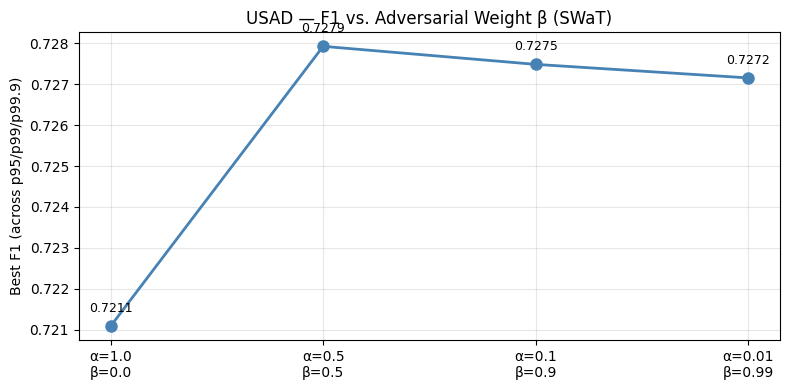

In [9]:
# F1 vs β — best F1 across all percentiles for each (alpha, beta) pair
best_per_ab = results_df.groupby(['alpha', 'beta'])['F1'].max().reset_index()

betas = [b for _, b in ALPHA_BETA]
f1s   = [
    best_per_ab.loc[(best_per_ab['alpha'] == a) & (best_per_ab['beta'] == b), 'F1'].values[0]
    for a, b in ALPHA_BETA
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(ALPHA_BETA)), f1s, marker='o', linewidth=2, markersize=8, color='steelblue')
for i, (f, (a, b)) in enumerate(zip(f1s, ALPHA_BETA)):
    ax.annotate(f'{f:.4f}', (i, f), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9)
ax.set_xticks(range(len(ALPHA_BETA)))
ax.set_xticklabels([f'α={a}\nβ={b}' for a, b in ALPHA_BETA])
ax.set_ylabel('Best F1 (across p95/p99/p99.9)')
ax.set_title('USAD — F1 vs. Adversarial Weight β (SWaT)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7 — Score Distribution

α=0.5, β=0.5  |  threshold=p92.0 (0.4715)
Normal  — mean: 0.2424  std: 0.1515
Attack  — mean: 0.4576  std: 0.1996
Separation ratio (attack mean / normal mean): 1.9×
(Compare: Feedforward AE 225×, LSTM-AE 324×)


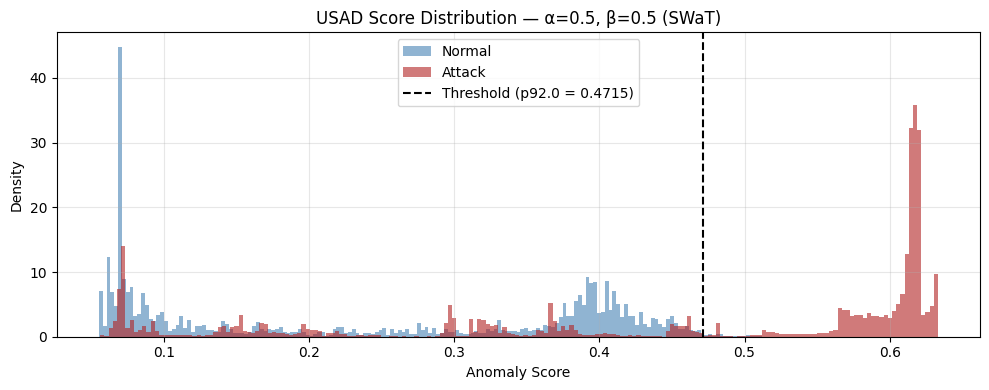

In [10]:
# Score distribution at the best (alpha, beta)
best_scores    = best_alpha * comp1 + best_beta * comp2
normal_scores  = best_scores[y_true == 0]
attack_scores  = best_scores[y_true == 1]

sep_ratio = attack_scores.mean() / max(normal_scores.mean(), 1e-9)

print(f'α={best_alpha}, β={best_beta}  |  threshold=p{best_pct} ({best_thresh:.4f})')
print(f'Normal  — mean: {normal_scores.mean():.4f}  std: {normal_scores.std():.4f}')
print(f'Attack  — mean: {attack_scores.mean():.4f}  std: {attack_scores.std():.4f}')
print(f'Separation ratio (attack mean / normal mean): {sep_ratio:.1f}×')
print(f'(Compare: Feedforward AE 225×, LSTM-AE 324×)')

clip = np.percentile(best_scores, 99.95)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.clip(normal_scores, 0, clip), bins=200, alpha=0.6,
        color='steelblue', label='Normal', density=True)
ax.hist(np.clip(attack_scores, 0, clip), bins=200, alpha=0.6,
        color='firebrick', label='Attack', density=True)
ax.axvline(best_thresh, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold (p{best_pct} = {best_thresh:.4f})')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density')
ax.set_title(f'USAD Score Distribution — α={best_alpha}, β={best_beta} (SWaT)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8 — Time-Series Visualization

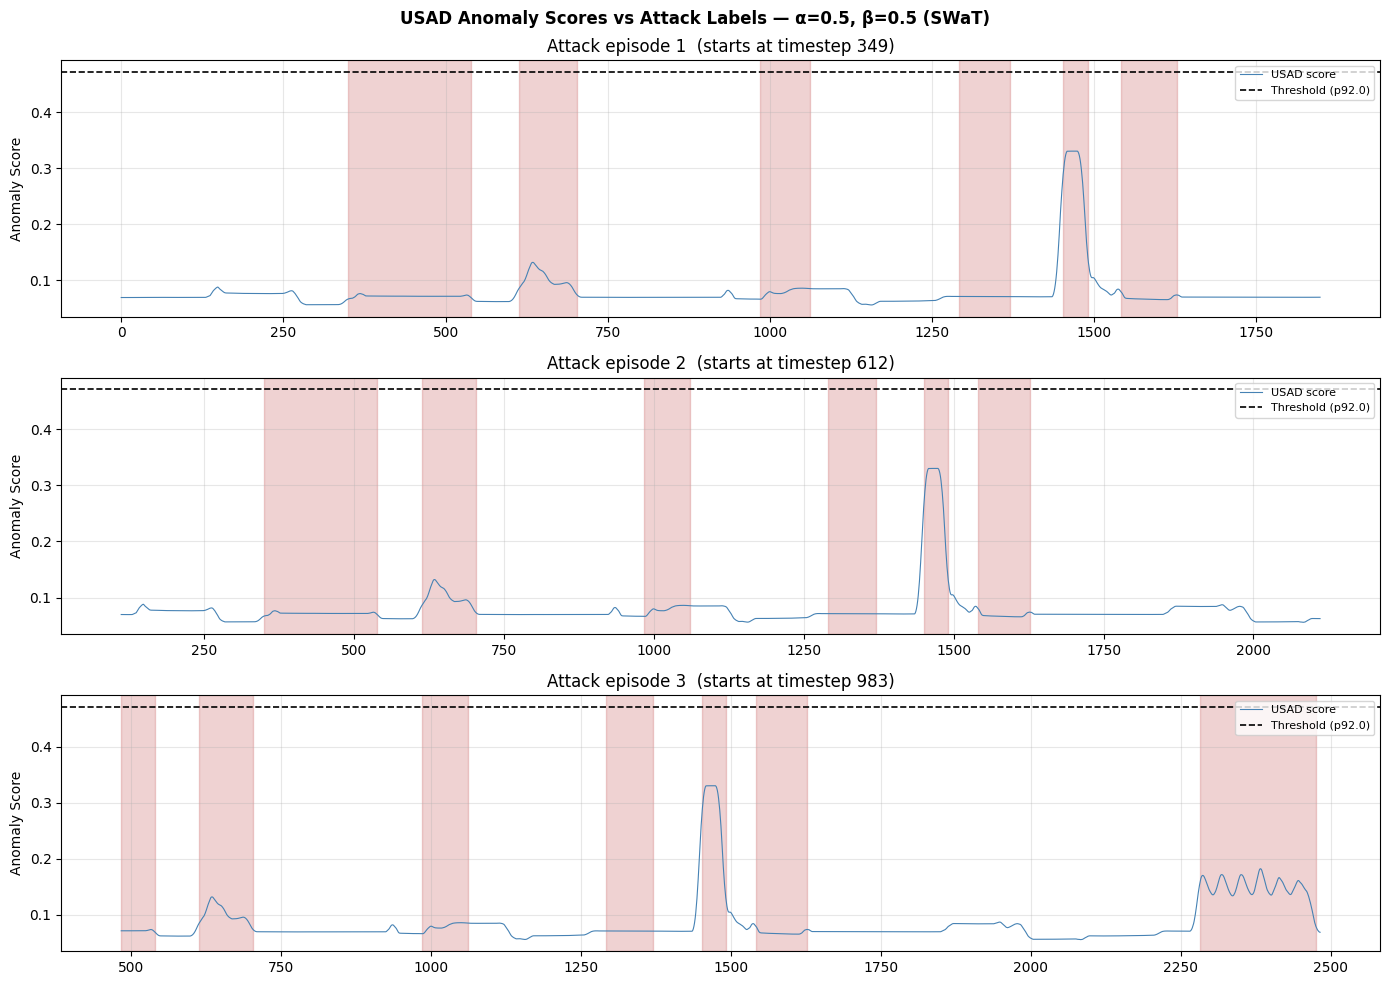

In [11]:
# Find first 3 attack episodes (normal→attack transitions)
transitions = np.where(np.diff(y_true) == 1)[0]
episode_starts = transitions[:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

pad_before = 500
pad_after  = 1500

for i, t_start in enumerate(episode_starts):
    t0 = max(0, t_start - pad_before)
    t1 = min(len(best_scores), t_start + pad_after)
    ts = np.arange(t0, t1)

    ax = axes[i]

    # Shade attack regions
    attack_mask = y_true[t0:t1]
    in_attack = False
    seg_start = t0
    for j, t in enumerate(ts):
        if attack_mask[j] and not in_attack:
            seg_start = t
            in_attack = True
        elif not attack_mask[j] and in_attack:
            ax.axvspan(seg_start, t, alpha=0.2, color='firebrick', label='Attack' if j < 5 else '')
            in_attack = False
    if in_attack:
        ax.axvspan(seg_start, ts[-1], alpha=0.2, color='firebrick')

    ax.plot(ts, best_scores[t0:t1], color='steelblue', linewidth=0.8, label='USAD score')
    ax.axhline(best_thresh, color='black', linestyle='--', linewidth=1.2,
               label=f'Threshold (p{best_pct})')
    ax.set_ylabel('Anomaly Score')
    ax.set_title(f'Attack episode {i+1}  (starts at timestep {t_start:,})')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'USAD Anomaly Scores vs Attack Labels — α={best_alpha}, β={best_beta} (SWaT)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Section 9 — Final Comparison Table

In [12]:
prior_results = [
    {'Method': 'Univariate Z-Score (Module 2)',  'F1': 0.4249, 'Precision': 0.2967, 'Recall': 0.7480},
    {'Method': 'Isolation Forest (Module 4)',     'F1': 0.5154, 'Precision': 0.4145, 'Recall': 0.6812},
    {'Method': 'Mahalanobis Distance (Module 3)', 'F1': 0.7240, 'Precision': 0.7277, 'Recall': 0.7202},
    {'Method': 'Feedforward AE (Module 5)',       'F1': 0.7264, 'Precision': 0.7494, 'Recall': 0.7047},
    {'Method': 'LSTM-AE (Module 6)',              'F1': 0.7533, 'Precision': 0.7845, 'Recall': 0.7244},
]

usad_result = {
    'Method':    f'USAD (Module 7, α={best_alpha}, β={best_beta}, p{best_pct})',
    'F1':        best_row['F1'],
    'Precision': best_row['Precision'],
    'Recall':    best_row['Recall'],
}

comp_df = pd.DataFrame(prior_results + [usad_result])

display(
    comp_df.style
    .format({'F1': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}'})
    .highlight_max(subset=['F1'], color='lightgreen')
)

print(f'\nUSAD vs LSTM-AE:        {best_row["F1"] - 0.7533:+.4f} F1')
print(f'USAD vs Feedforward AE: {best_row["F1"] - 0.7264:+.4f} F1')

,Method,F1,Precision,Recall
0,Univariate Z-Score (Module 2),0.4249,0.2967,0.7480
1,Isolation Forest (Module 4),0.5154,0.4145,0.6812
2,Mahalanobis Distance (Module 3),0.7240,0.7277,0.7202
3,Feedforward AE (Module 5),0.7264,0.7494,0.7047
4,LSTM-AE (Module 6),0.7533,0.7845,0.7244
5,"USAD (Module 7, α=0.5, β=0.5, p92.0)",0.7279,0.9172,0.6034



USAD vs LSTM-AE:        -0.0254 F1
USAD vs Feedforward AE: +0.0015 F1


## Section 10 — Analysis

*Fill in after running.*

**F1 result:** [TBD] at α=[TBD], β=[TBD], p[TBD]

**Separation ratio:** [TBD]× (compare: Feedforward AE 225×, LSTM-AE 324×)

**α/β sensitivity:**
- At β=0: USAD degenerates to a standard feedforward AE — score is just the AE1 reconstruction error. Should reproduce F1 close to Module 5's 0.7264.
- At β→1: adversarial amplification dominates. If F1 rises, adversarial training adds real signal on SWaT. If F1 falls, the adversarial term amplifies false alarms on borderline-normal windows.

**Comparison with LSTM-AE:**
- If USAD > 0.7533: loss function design (adversarial term) matters as much as architecture (LSTM). Adversarial training compensates for the absence of temporal modeling.
- If USAD ≤ 0.7533: temporal context captured by the LSTM over 60-step windows is not reproducible by the 12-step windowed MLP, even with adversarial amplification. SWaT's slow drift attacks inherently require longer-range temporal structure.

**Sigmoid decoder note:** The paper specifies Sigmoid as the decoder's final activation. Since inputs are StandardScaler-normalized (unbounded), Sigmoid compresses all reconstructions into [0, 1]. Any scaled value outside this range incurs a systematic reconstruction error floor, which affects both normal and attack scores equally. This may reduce the normal/attack separation ratio relative to an unbounded decoder.